In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
from sklearn import linear_model, preprocessing, model_selection, pipeline, metrics, cluster
import matplotlib.pyplot as plt

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

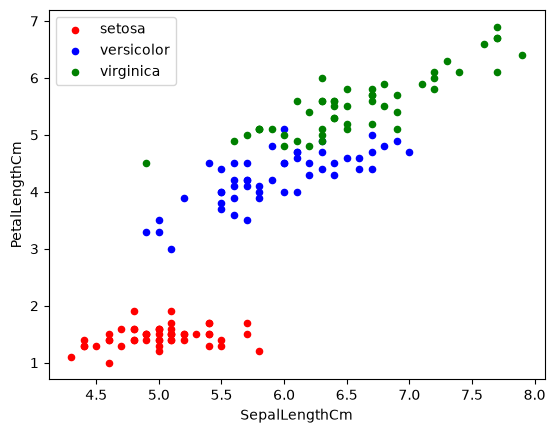

In [5]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

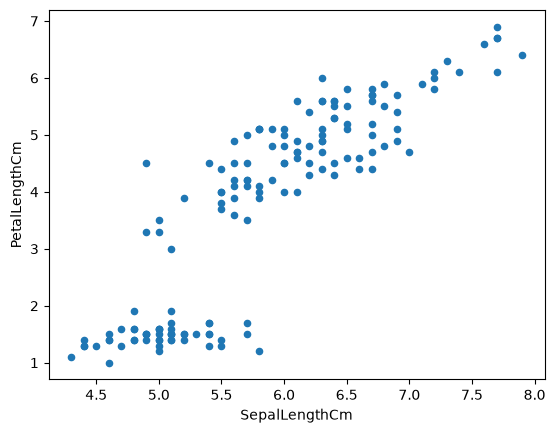

In [7]:
X = df[['SepalLengthCm', 'PetalLengthCm']]
X.plot.scatter(0, 1)

In [9]:

pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', cluster.KMeans(n_clusters=3, random_state=123)),
])
y_pred = pipe.fit_predict(X)


In [10]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 2, 2, 1, 0, 2, 1, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2], dtype=int32)

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

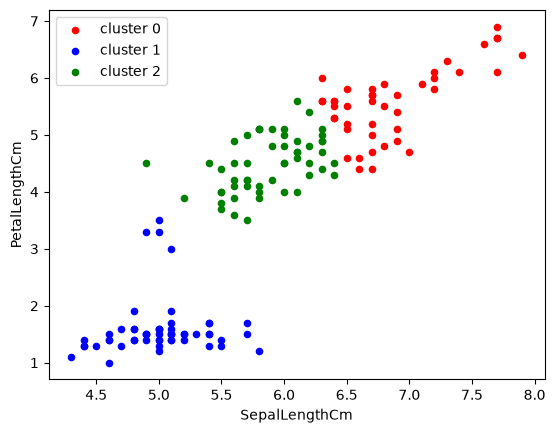

In [12]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[y_pred == 0].plot.scatter(0, 1, color = 'red', ax = ax, label = 'cluster 0')
X[y_pred == 1].plot.scatter(0, 1, color = 'blue', ax = ax, label='cluster 1')
X[y_pred == 2].plot.scatter(0, 1, color = 'green', ax = ax, label = 'cluster 2')

In [14]:
kmeans = pipe.steps[-1][-1]
kmeans.n_clusters

3

In [16]:
centers = pipe.steps[0][1].inverse_transform(kmeans.cluster_centers_)
centers

array([[6.85813953, 5.56744186],
       [5.00555556, 1.59814815],
       [5.87358491, 4.49245283]])

<Axes: xlabel='0', ylabel='1'>

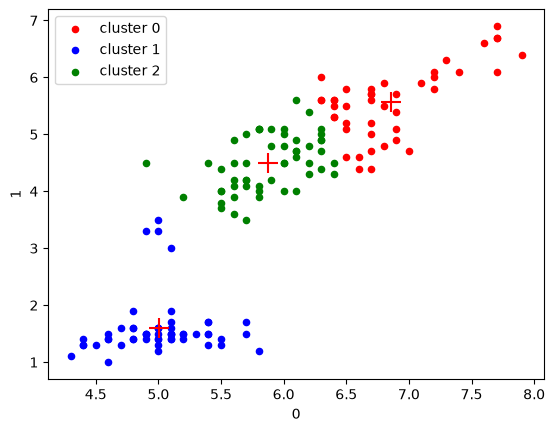

In [24]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[y_pred == 0].plot.scatter(0, 1, color = 'red', ax = ax, label = 'cluster 0')
X[y_pred == 1].plot.scatter(0, 1, color = 'blue', ax = ax, label='cluster 1')
X[y_pred == 2].plot.scatter(0, 1, color = 'green', ax = ax, label = 'cluster 2')

centers = pipe.steps[0][1].inverse_transform(kmeans.cluster_centers_)
pd.DataFrame(centers).plot.scatter(0, 1, ax = ax, marker = "+", s = 200, color = "red")

In [25]:
metrics.homogeneity_score(y_pred, df.Species)

0.5853247279721064